<a href="https://colab.research.google.com/github/Yashika007-J/Sales-Data-Analyst/blob/main/Sales_Data_Analyst8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [28]:
df = pd.read_csv("/content/Afficionado Coffee Roasters.xlsx - Transactions (1).csv")
df.head()

,transaction_id,year,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2025,7:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2025,7:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2025,7:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2025,7:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2025,7:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [29]:
df.shape

(149116, 11)

In [30]:
df.isnull().sum()

,0
transaction_id,0
year,0
transaction_time,0
transaction_qty,0
store_id,0
store_location,0
product_id,0
unit_price,0
product_category,0
product_type,0


In [31]:
df.columns

Index(['transaction_id', 'year', 'transaction_time', 'transaction_qty',
       'store_id', 'store_location', 'product_id', 'unit_price',
       'product_category', 'product_type', 'product_detail'],
      dtype='object')

In [32]:
df.describe()

,transaction_id,year,transaction_qty,store_id,product_id,unit_price
count,149116.000000,149116.0,149116.000000,149116.000000,149116.000000,149116.000000
mean,74737.371872,2025.0,1.438276,5.342063,47.918607,3.382219
std,43153.600016,0.0,0.542509,2.074241,17.930020,2.658723
min,1.000000,2025.0,1.000000,3.000000,1.000000,0.800000
25%,37335.750000,2025.0,1.000000,3.000000,33.000000,2.500000
50%,74727.500000,2025.0,1.000000,5.000000,47.000000,3.000000
75%,112094.250000,2025.0,2.000000,8.000000,60.000000,3.750000
max,149456.000000,2025.0,8.000000,8.000000,87.000000,45.000000


In [33]:
df.columns.tolist()

['transaction_id',
 'year',
 'transaction_time',
 'transaction_qty',
 'store_id',
 'store_location',
 'product_id',
 'unit_price',
 'product_category',
 'product_type',
 'product_detail']

In [34]:
df.describe()

,transaction_id,year,transaction_qty,store_id,product_id,unit_price
count,149116.000000,149116.0,149116.000000,149116.000000,149116.000000,149116.000000
mean,74737.371872,2025.0,1.438276,5.342063,47.918607,3.382219
std,43153.600016,0.0,0.542509,2.074241,17.930020,2.658723
min,1.000000,2025.0,1.000000,3.000000,1.000000,0.800000
25%,37335.750000,2025.0,1.000000,3.000000,33.000000,2.500000
50%,74727.500000,2025.0,1.000000,5.000000,47.000000,3.000000
75%,112094.250000,2025.0,2.000000,8.000000,60.000000,3.750000
max,149456.000000,2025.0,8.000000,8.000000,87.000000,45.000000


In [35]:

# transaction_time proper time format convrt
df['transaction_time'] = pd.to_datetime(df['transaction_time'], format='%H:%M:%S')

# New columns
df['hour'] = df['transaction_time'].dt.hour
df['day_of_week'] = df['transaction_time'].dt.dayofweek  # 0=Monday, 6=Sunday
df['day_name'] = df['transaction_time'].dt.day_name()
df['revenue'] = df['transaction_qty'] * df['unit_price']

# Time bucket function
def time_bucket(hour):
    if 6 <= hour <= 11:
        return 'Morning (6-11)'
    elif 12 <= hour <= 16:
        return 'Afternoon (12-16)'
    elif 17 <= hour <= 21:
        return 'Evening (17-21)'
    else:
        return 'Late Hours (22-5)'

df['time_bucket'] = df['hour'].apply(time_bucket)

# Check
print(df[['transaction_time', 'hour', 'day_name', 'revenue', 'time_bucket']].head(10))
print("\nNew shape:", df.shape)

     transaction_time  hour day_name  revenue     time_bucket
0 1900-01-01 07:06:11     7   Monday     6.00  Morning (6-11)
1 1900-01-01 07:08:56     7   Monday     6.20  Morning (6-11)
2 1900-01-01 07:14:04     7   Monday     9.00  Morning (6-11)
3 1900-01-01 07:20:24     7   Monday     2.00  Morning (6-11)
4 1900-01-01 07:22:41     7   Monday     6.20  Morning (6-11)
5 1900-01-01 07:22:41     7   Monday     3.00  Morning (6-11)
6 1900-01-01 07:25:49     7   Monday     2.00  Morning (6-11)
7 1900-01-01 07:33:34     7   Monday     4.00  Morning (6-11)
8 1900-01-01 07:39:13     7   Monday     4.25  Morning (6-11)
9 1900-01-01 07:39:34     7   Monday     7.00  Morning (6-11)

New shape: (149116, 16)


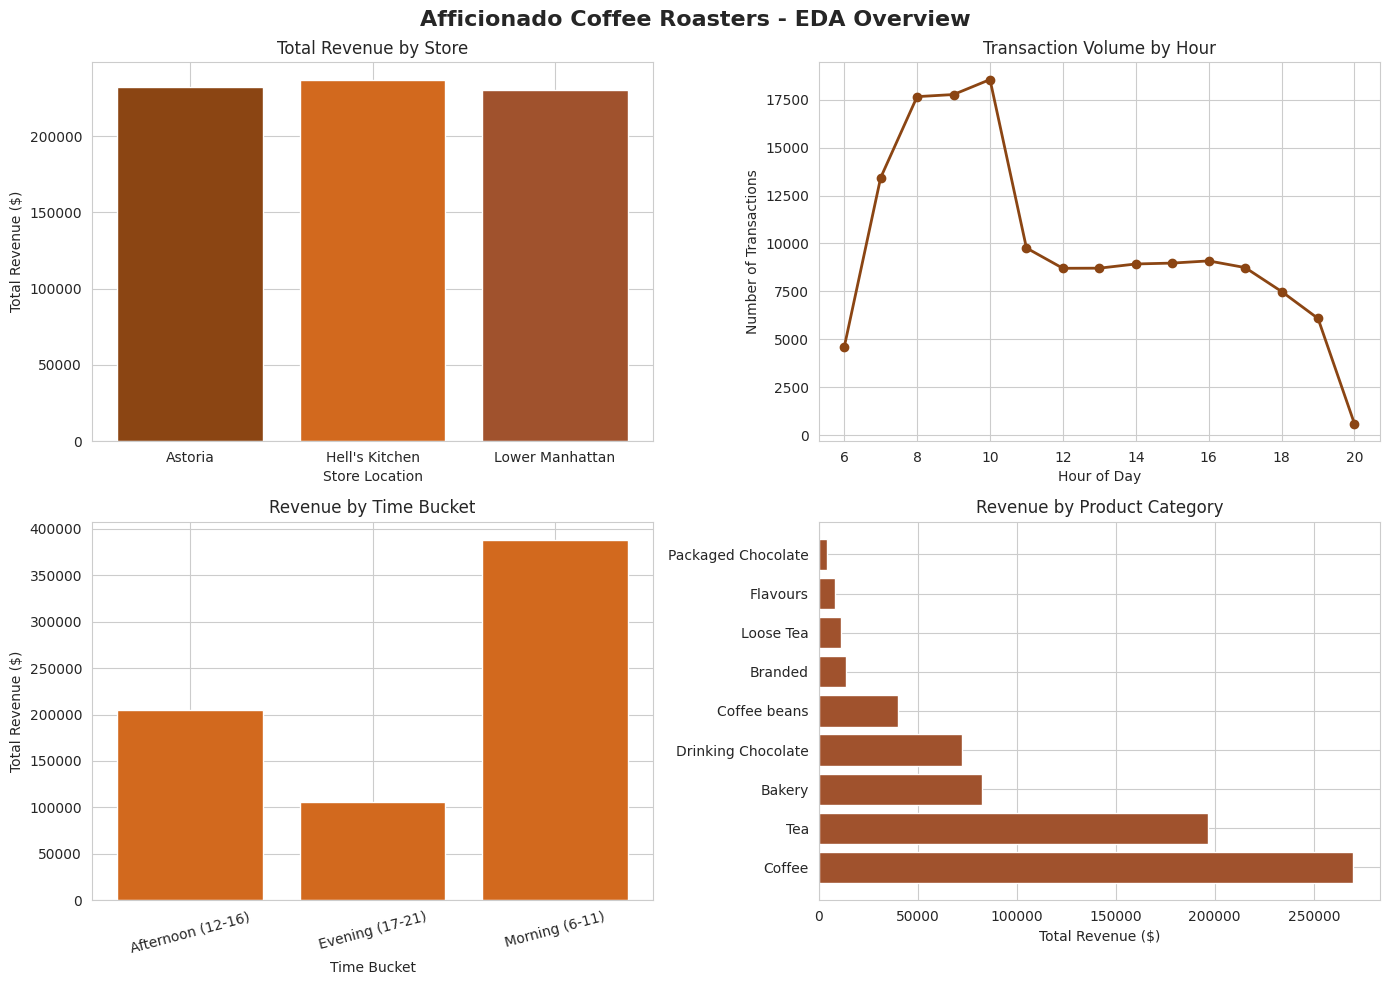

In [36]:
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Afficionado Coffee Roasters - EDA Overview', fontsize=16, fontweight='bold')

# 1. Revenue by Store Location
store_rev = df.groupby('store_location')['revenue'].sum().reset_index()
axes[0,0].bar(store_rev['store_location'], store_rev['revenue'], color=['#8B4513','#D2691E','#A0522D'])
axes[0,0].set_title('Total Revenue by Store')
axes[0,0].set_xlabel('Store Location')
axes[0,0].set_ylabel('Total Revenue ($)')

# 2. Transactions by Hour
hour_count = df.groupby('hour')['transaction_id'].count()
axes[0,1].plot(hour_count.index, hour_count.values, color='#8B4513', linewidth=2, marker='o')
axes[0,1].set_title('Transaction Volume by Hour')
axes[0,1].set_xlabel('Hour of Day')
axes[0,1].set_ylabel('Number of Transactions')

# 3. Revenue by Time Bucket
bucket_rev = df.groupby('time_bucket')['revenue'].sum()
axes[1,0].bar(bucket_rev.index, bucket_rev.values, color='#D2691E')
axes[1,0].set_title('Revenue by Time Bucket')
axes[1,0].set_xlabel('Time Bucket')
axes[1,0].set_ylabel('Total Revenue ($)')
axes[1,0].tick_params(axis='x', rotation=15)

# 4. Revenue by Product Category
cat_rev = df.groupby('product_category')['revenue'].sum().sort_values(ascending=False)
axes[1,1].barh(cat_rev.index, cat_rev.values, color='#A0522D')
axes[1,1].set_title('Revenue by Product Category')
axes[1,1].set_xlabel('Total Revenue ($)')

plt.tight_layout()
plt.show()

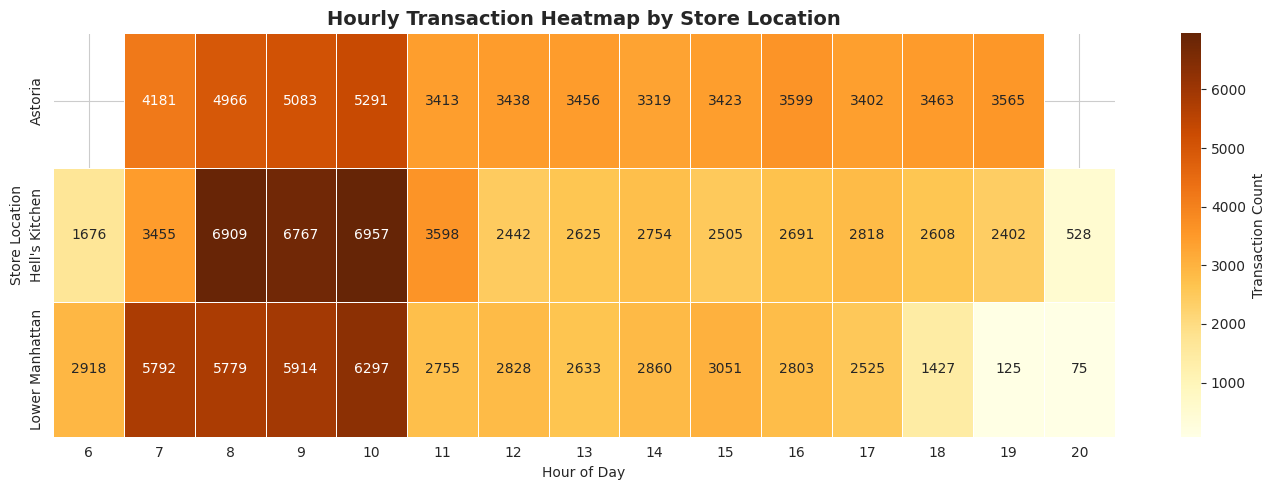

In [37]:
# Hourly heatmap - store wise
pivot = df.groupby(['store_location', 'hour'])['transaction_id'].count().unstack()

plt.figure(figsize=(14, 5))
sns.heatmap(pivot,
            cmap='YlOrBr',
            annot=True,
            fmt='.0f', # Changed from 'd' to '.0f' to handle float values
            linewidths=0.5,
            cbar_kws={'label': 'Transaction Count'})

plt.title('Hourly Transaction Heatmap by Store Location', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Store Location')
plt.tight_layout()
plt.show()

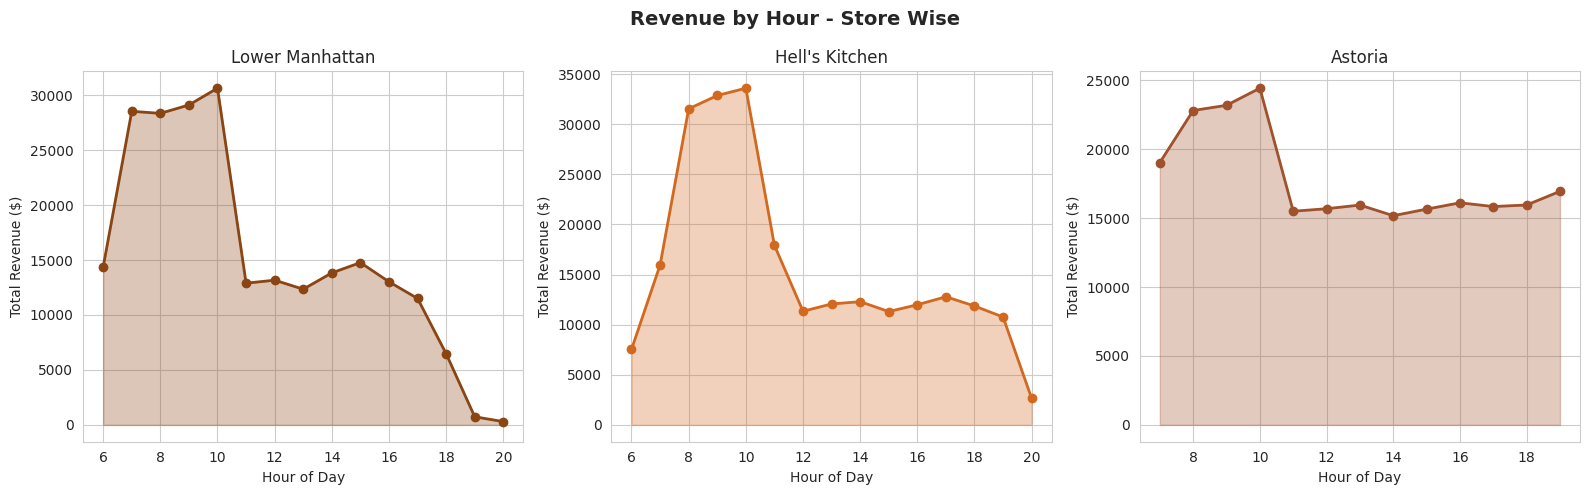

In [38]:
# Revenue by product category per store
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Revenue by Hour - Store Wise', fontsize=14, fontweight='bold')

stores = df['store_location'].unique()
colors = ['#8B4513', '#D2691E', '#A0522D']

for i, store in enumerate(stores):
    store_df = df[df['store_location'] == store]
    hourly_rev = store_df.groupby('hour')['revenue'].sum()

    axes[i].plot(hourly_rev.index, hourly_rev.values,
                 color=colors[i], linewidth=2, marker='o')
    axes[i].set_title(f'{store}')
    axes[i].set_xlabel('Hour of Day')
    axes[i].set_ylabel('Total Revenue ($)')
    axes[i].fill_between(hourly_rev.index, hourly_rev.values,
                          alpha=0.3, color=colors[i])

plt.tight_layout()
plt.show()

In [39]:
# Summary Statistics Table
summary = df.groupby('store_location').agg(
    Total_Revenue=('revenue', 'sum'),
    Total_Transactions=('transaction_id', 'count'),
    Avg_Revenue_Per_Transaction=('revenue', 'mean'),
    Peak_Hour=('hour', lambda x: x.value_counts().idxmax())
).round(2).reset_index()

print("=" * 60)
print("AFFICIONADO COFFEE ROASTERS - STORE SUMMARY")
print("=" * 60)
print(summary.to_string(index=False))

print("\n")
print("=" * 60)
print("TIME BUCKET SUMMARY")
print("=" * 60)
bucket_summary = df.groupby('time_bucket').agg(
    Total_Revenue=('revenue', 'sum'),
    Total_Transactions=('transaction_id', 'count'),
).round(2).reset_index()
print(bucket_summary.to_string(index=False))

AFFICIONADO COFFEE ROASTERS - STORE SUMMARY
 store_location  Total_Revenue  Total_Transactions  Avg_Revenue_Per_Transaction  Peak_Hour
        Astoria      232243.91               50599                         4.59         10
 Hell's Kitchen      236511.17               50735                         4.66         10
Lower Manhattan      230057.25               47782                         4.81         10


TIME BUCKET SUMMARY
      time_bucket  Total_Revenue  Total_Transactions
Afternoon (12-16)      204720.83               44427
  Evening (17-21)      105802.83               22938
   Morning (6-11)      388288.67               81751


In [40]:
# Cleaned dataset save karo
df.to_csv('afficionado_cleaned.csv', index=False)

# Download karo Colab se
from google.colab import files
files.download('afficionado_cleaned.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>